In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [16]:
data_file = np.load('downloaded_data/2D_NS_Re40.npy')
# data_file = np.load('downloaded_data/2D_NS_Re500.npy')
# data_file = np.load('downloaded_data/2D_NS_Re5000.npy')
data_file.shape

(200, 501, 64, 64)

In [17]:
w_data = data_file.reshape(data_file.shape[0] * data_file.shape[1], data_file.shape[2] * data_file.shape[3])

In [18]:
from sklearn.decomposition import PCA

flat_data = w_data

# Initialize and fit the PCA model
pca = PCA(n_components=10)
principal_components = pca.fit_transform(flat_data)

print("PCA fitting complete.")

PCA fitting complete.


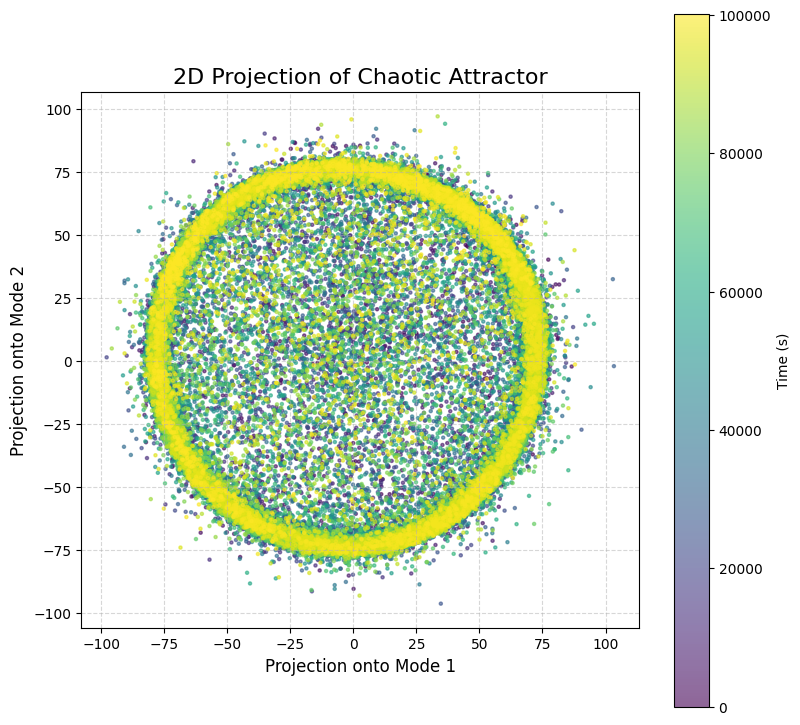

In [19]:
plt.figure(figsize=(9, 9))
    
# We can color the points by time to see the evolution, using a subset for clarity
# num_points_to_plot = 5000 # Plot a subset to avoid a dense blob
# subset_indices = np.linspace(0, len(principal_components) - 1, num_points_to_plot, dtype=int)
time_subset = np.arange(len(principal_components))

sc = plt.scatter(
	principal_components[:, 0],
	principal_components[:, 1],
	c=time_subset,
	cmap='viridis',
	s=5,
	alpha=0.6
)

plt.colorbar(sc, label='Time (s)')
plt.xlabel("Projection onto Mode 1", fontsize=12)
plt.ylabel("Projection onto Mode 2", fontsize=12)
plt.title("2D Projection of Chaotic Attractor", fontsize=16)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()